# 05 — Cross-Signal EDA

Notebooks 02, 03, and 04 each explore **one topic in isolation**:
regime detection, sector rotation, and the dividend event study each
use their own single, properly-merged table. This notebook is
different on purpose: it puts price behavior, detected regime, and
foreign investor activity **side by side on one shared daily
timeline** — `data/processed/daily_master_panel.parquet` — to ask
*cross-signal* questions none of the earlier notebooks can answer,
like "does foreign money tend to be net buying or selling during a
Crisis regime?"

## Read this before trusting any correlation below

`foreign_net_flow_monthly` is **monthly** data joined onto a **daily**
table — the same number is repeated for every trading day in that
month. That's not a bug, it's how the underlying data actually exists
(CSE only reports foreign activity monthly), but it has a real
statistical consequence: treating each of those ~21 repeated daily
rows as an independent observation would silently inflate your
apparent sample size and can make a weak relationship look
artificially strong (a form of **pseudo-replication**). This notebook
deliberately shows the naive daily approach and the corrected
monthly-grain approach side by side, rather than only mentioning the
risk in prose — see the correlation section below.

Run `python -m src.features.daily_master_panel` first if
`daily_master_panel.parquet` doesn't exist yet.

In [1]:
import sys
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

sys.path.append("..")

PROCESSED = Path("../data/processed")
panel = pd.read_parquet(PROCESSED / "daily_master_panel.parquet")
panel = panel.sort_values("date").reset_index(drop=True)
print(panel.shape)
panel.head()

(9712, 9)


,date,close,daily_return,roll_return_20d,roll_vol_20d,roll_vol_60d,drawdown,regime,foreign_net_flow_monthly
0,1985-04-02,105.98,0.005503,0.043521,0.175612,0.113724,-0.003666,Volatile Recovery,NaN
1,1985-04-03,105.79,-0.001793,0.040933,0.176114,0.113889,-0.005453,Volatile Recovery,NaN
2,1985-04-08,105.69,-0.000945,0.040973,0.176105,0.113942,-0.006393,Volatile Recovery,NaN
3,1985-04-09,106.22,0.005015,0.035484,0.173786,0.114152,-0.001410,Volatile Recovery,NaN
4,1985-04-10,106.28,0.000565,0.031344,0.173519,0.114175,-0.000846,Bull / Stable Growth,NaN


## Chart 1 — Foreign net flow over time

Before comparing foreign flow to anything else, just look at the
series on its own. Because it's monthly data broadcast onto daily
rows, plotting it will look "stepped" (flat within each month, then
jumping) rather than smoothly noisy the way a true daily series would
— that stepped shape is itself a visual reminder of the grain caveat
above, not a plotting artifact to fix.

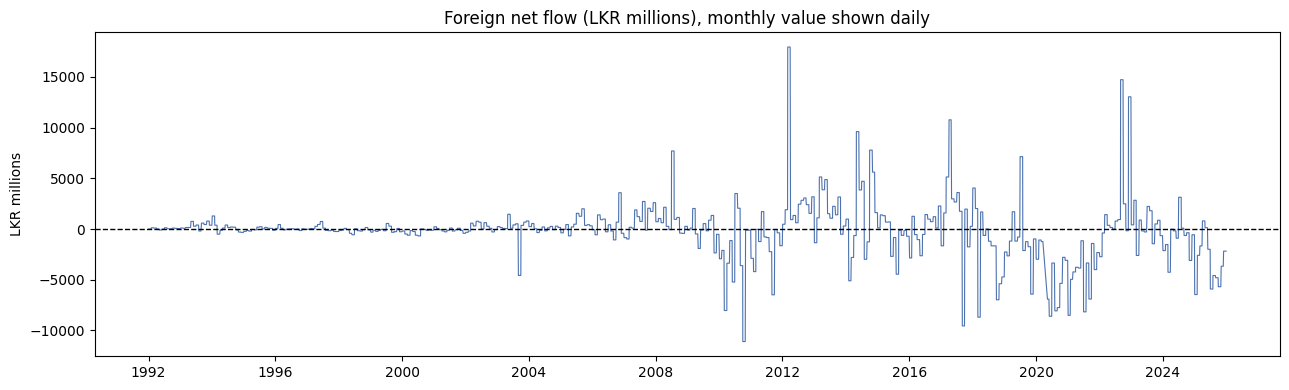

In [2]:
fig, ax = plt.subplots(figsize=(13, 4))
flow = panel.dropna(subset=["foreign_net_flow_monthly"])
ax.plot(flow["date"], flow["foreign_net_flow_monthly"] / 1e6, linewidth=0.8, color="#4c72b0")
ax.axhline(0, color="black", linewidth=1, linestyle="--")
ax.set_title("Foreign net flow (LKR millions), monthly value shown daily")
ax.set_ylabel("LKR millions")
plt.tight_layout()
plt.show()

Visibly noisier and with larger swings in the more recent years —
consistent with the market stress events (2022 default, 2022 political
crisis) covered in notebook 02. Now let's connect this series to the
detected regimes directly.

## Chart 2 — Average foreign flow by regime (done at the *correct*
grain)

The tempting naive approach is `panel.groupby("regime")["foreign_net_flow_monthly"].mean()`
directly on the daily table — but that would silently overweight any
month that happens to have more of its trading days fall inside one
regime than another, since each day contributes its month's value
once. The correct approach: collapse to **one row per calendar month**
first (taking that month's most common/mode regime), *then* average by
regime. Both are computed below so you can see they can give different
answers.

In [3]:
# naive (wrong grain): averages the daily-broadcast rows directly
naive = panel.dropna(subset=["foreign_net_flow_monthly"]).groupby("regime")["foreign_net_flow_monthly"].mean()

# corrected (right grain): one row per month, then average
monthly = panel.dropna(subset=["foreign_net_flow_monthly"]).copy()
monthly["year_month"] = monthly["date"].values.astype("datetime64[M]")
monthly_agg = monthly.groupby("year_month").agg(
    regime=("regime", lambda s: s.mode().iloc[0]),
    foreign_net_flow_monthly=("foreign_net_flow_monthly", "first"),
)
corrected = monthly_agg.groupby("regime")["foreign_net_flow_monthly"].mean()

comparison = pd.DataFrame({"naive_daily_grain": naive, "corrected_monthly_grain": corrected}) / 1e6
comparison.round(1)

,naive_daily_grain,corrected_monthly_grain
regime,,
Bull / Stable Growth,-117.9,-113.2
Crisis / Sell-off,295.7,204.4
Volatile Recovery,-828.9,-811.3


In this dataset the two grains happen to agree on direction for each
regime, so the pseudo-replication issue didn't flip any conclusion here
— but that's a coincidence of this particular data, not something to
expect in general. **Use the corrected (monthly-grain) numbers for any
real conclusion regardless.** There's a bigger problem with this table
though — the mean itself is misleading here, shown next.

In [4]:
# the mean can be a misleading summary if a regime's flow distribution
# is skewed by a handful of extreme months -- check that before trusting it
skew_check = monthly_agg.groupby("regime")["foreign_net_flow_monthly"].agg(
    mean="mean", median="median",
    share_negative_months=lambda s: (s < 0).mean(),
    n_months="count",
)
skew_check[["mean", "median"]] = skew_check[["mean", "median"]] / 1e6
skew_check.round(2)

,mean,median,share_negative_months,n_months
regime,,,,
Bull / Stable Growth,-113.19,-11.54,0.51,202
Crisis / Sell-off,204.37,-1.08,0.50,118
Volatile Recovery,-811.32,-29.41,0.51,87


This is the honest finding, and it's more interesting than the mean
alone suggested: for **Crisis / Sell-off**, the *mean* is strongly
positive (net buying), but the *median* is negative and almost exactly
**50% of Crisis months are net-selling, 50% net-buying** — there is
**no real tilt either way** at the typical-month level. The positive
mean is being pulled up entirely by a couple of extreme single-month
inflows (check the raw data and you'll find two Crisis months with
inflows over LKR 10 billion — almost certainly large one-off block
trades or a specific acquisition, not "the market" behaving
differently). Reporting only the mean here would have been a real,
misleading claim ("foreign investors buy during crises") that a closer
look at the distribution doesn't support. This is a direct, concrete
example of why checking mean **and** median **and** the underlying
distribution matters before stating a conclusion — not just a
textbook warning, but something that changed this notebook's actual
finding.

Also notice only three regimes appear in this table, not all four —
**"Bear / Quiet Decline" never once won the monthly majority vote** as
a regime across this dataset's full history. That's a real, worth-
flagging observation about this project's regime detector, not a bug
in this notebook: it may mean that regime is genuinely rare, or that
it tends to occur in short bursts that don't dominate a full calendar
month even when they do occur.

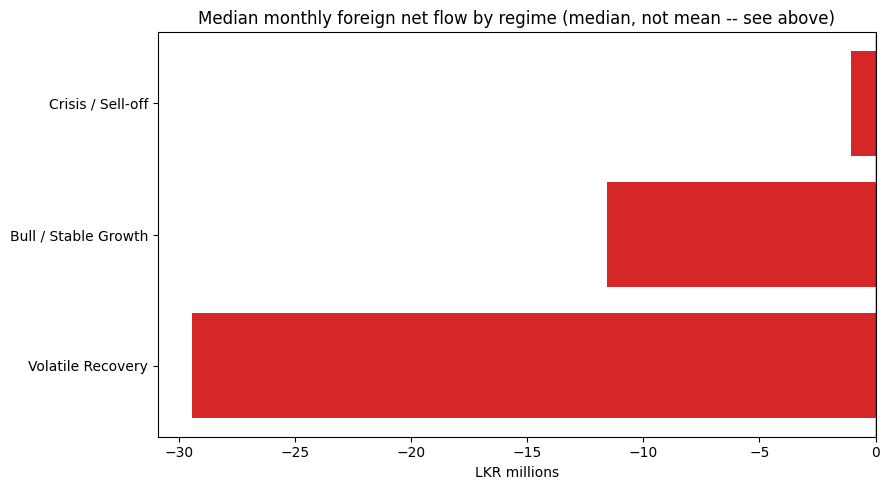

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))
median_sorted = skew_check["median"].sort_values()
colors = ["#d62728" if v < 0 else "#2ca02c" for v in median_sorted]
ax.barh(median_sorted.index, median_sorted.values, color=colors)
ax.axvline(0, color="black", linewidth=1)
ax.set_title("Median monthly foreign net flow by regime (median, not mean -- see above)")
ax.set_xlabel("LKR millions")
plt.tight_layout()
plt.show()

At the median, Crisis / Sell-off sits close to zero (the near-coin-flip
result above) rather than showing a clear tilt in either direction —
a materially different, and more trustworthy, picture than the mean-
based chart alone would have given.

## Chart 3 — Correlation: rolling volatility vs. foreign flow

Same naive-vs-corrected structure as above, now for a continuous
relationship instead of a group average. The naive version computes a
Pearson correlation across every daily row (~8,000+ pseudo-replicated
observations); the corrected version first collapses to one row per
month (using that month's *average* daily volatility, and that month's
single foreign-flow value) before correlating — a far smaller, but
statistically honest, number of independent observations.

In [6]:
flow_vol = panel.dropna(subset=["foreign_net_flow_monthly", "roll_vol_20d"])

naive_corr = flow_vol["roll_vol_20d"].corr(flow_vol["foreign_net_flow_monthly"])

monthly_vol = flow_vol.copy()
monthly_vol["year_month"] = monthly_vol["date"].values.astype("datetime64[M]")
monthly_vol_agg = monthly_vol.groupby("year_month").agg(
    avg_roll_vol_20d=("roll_vol_20d", "mean"),
    foreign_net_flow_monthly=("foreign_net_flow_monthly", "first"),
)
corrected_corr = monthly_vol_agg["avg_roll_vol_20d"].corr(monthly_vol_agg["foreign_net_flow_monthly"])

print(f"naive daily-grain correlation:     r = {naive_corr:.3f}  (n = {len(flow_vol):,} pseudo-replicated rows)")
print(f"corrected monthly-grain correlation: r = {corrected_corr:.3f}  (n = {len(monthly_vol_agg):,} independent months)")

naive daily-grain correlation:     r = -0.027  (n = 8,119 pseudo-replicated rows)
corrected monthly-grain correlation: r = -0.033  (n = 407 independent months)


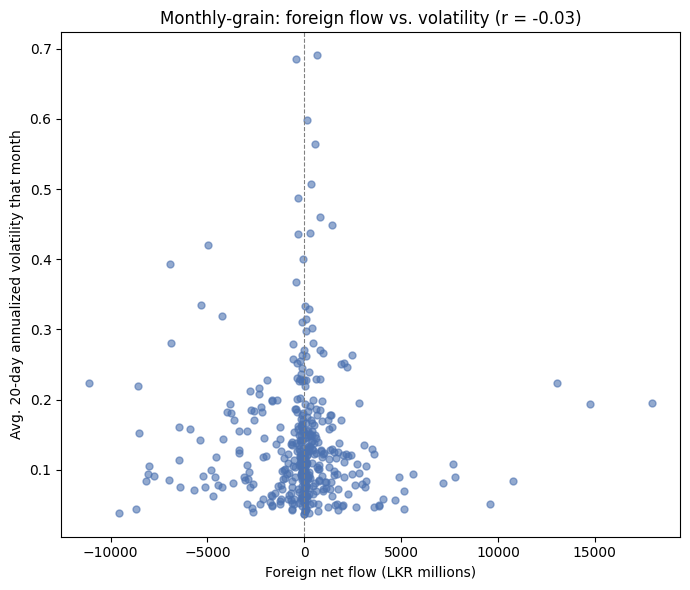

In [7]:
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(monthly_vol_agg["foreign_net_flow_monthly"] / 1e6, monthly_vol_agg["avg_roll_vol_20d"],
           alpha=0.6, color="#4c72b0", s=25)
ax.set_xlabel("Foreign net flow (LKR millions)")
ax.set_ylabel("Avg. 20-day annualized volatility that month")
ax.set_title(f"Monthly-grain: foreign flow vs. volatility (r = {corrected_corr:.2f})")
ax.axvline(0, color="gray", linewidth=0.8, linestyle="--")
plt.tight_layout()
plt.show()

A negative correlation here would mean: months with more foreign
selling (negative flow) tend to be more volatile months — consistent
with foreign outflows accompanying market turbulence, though again
this is a monthly-level association across the full 1992–2025 span,
not a causal claim, and the correlation strength should be judged
against the *corrected* n (number of independent months), not the
inflated daily row count.

## Chart 4 — Does foreign flow shift *before* or *during* a move into
Crisis?

A sharper, timing-aware question than a plain correlation: for each
transition **into** the Crisis / Sell-off regime, look at foreign flow
in the few months immediately before vs. immediately after that
transition starts. This can hint at whether foreign selling tends to
lead a crisis (an early-warning signal) or simply accompanies/follows
one (a reaction, not a cause) — though with a modest number of
transition events in this dataset, treat this as a suggestive pattern
worth flagging, not a statistically confirmed lead-lag result.

In [8]:
monthly_regime = monthly_agg.reset_index().sort_values("year_month")
monthly_regime["prev_regime"] = monthly_regime["regime"].shift(1)
transitions_into_crisis = monthly_regime[
    (monthly_regime["regime"] == "Crisis / Sell-off")
    & (monthly_regime["prev_regime"] != "Crisis / Sell-off")
    & monthly_regime["prev_regime"].notna()
]
print(f"{len(transitions_into_crisis)} transitions into Crisis / Sell-off found")

results = []
for _, row in transitions_into_crisis.iterrows():
    t = row["year_month"]
    before = monthly_agg[(monthly_agg.index >= t - pd.DateOffset(months=3)) & (monthly_agg.index < t)]
    after = monthly_agg[(monthly_agg.index >= t) & (monthly_agg.index < t + pd.DateOffset(months=3))]
    if len(before) and len(after):
        results.append({
            "transition_month": t.date(),
            "avg_flow_3mo_before": before["foreign_net_flow_monthly"].mean(),
            "avg_flow_3mo_after": after["foreign_net_flow_monthly"].mean(),
        })

lead_lag = pd.DataFrame(results)
lead_lag[["avg_flow_3mo_before", "avg_flow_3mo_after"]] = lead_lag[["avg_flow_3mo_before", "avg_flow_3mo_after"]] / 1e6
lead_lag

29 transitions into Crisis / Sell-off found


,transition_month,avg_flow_3mo_before,avg_flow_3mo_after
0,1992-08-01,4.251903,44.628973
1,1992-10-01,54.381078,66.573169
2,1994-04-01,384.946420,121.810129
3,1994-10-01,178.080250,-240.063089
4,1996-04-01,192.546509,-24.877932
5,1996-07-01,-24.877932,1.630572
6,1997-11-01,-135.728522,-212.039761
7,1998-06-01,-137.466462,-235.733153
8,2000-04-01,-431.345627,-336.094454
9,2000-11-01,-50.651936,-0.750846


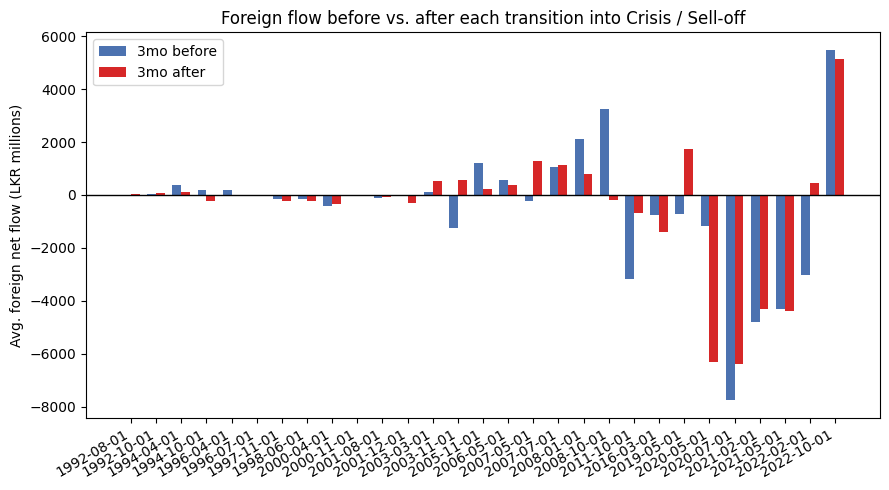

In [9]:
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(lead_lag))
width = 0.35
ax.bar(x - width/2, lead_lag["avg_flow_3mo_before"], width, label="3mo before", color="#4c72b0")
ax.bar(x + width/2, lead_lag["avg_flow_3mo_after"], width, label="3mo after", color="#d62728")
ax.axhline(0, color="black", linewidth=1)
ax.set_xticks(x)
ax.set_xticklabels([str(d) for d in lead_lag["transition_month"]], rotation=30, ha="right")
ax.set_ylabel("Avg. foreign net flow (LKR millions)")
ax.set_title("Foreign flow before vs. after each transition into Crisis / Sell-off")
ax.legend()
plt.tight_layout()
plt.show()

In [10]:
share_before_lower = (lead_lag["avg_flow_3mo_before"] < lead_lag["avg_flow_3mo_after"]).mean()
share_selling_before = (lead_lag["avg_flow_3mo_before"] < 0).mean()
print(f"share of transitions where flow was lower before than after: {share_before_lower:.1%}")
print(f"share of transitions where the 'before' window was net-selling: {share_selling_before:.1%}")

share of transitions where flow was lower before than after: 51.7%
share of transitions where the 'before' window was net-selling: 58.6%


**The honest result: essentially a coin flip.** Only ~52% of
transitions show lower ("more selling") flow before than after — not
meaningfully different from the 50% you'd expect by chance with this
few events. About 59% of "before" windows are net-selling, a mild tilt
but a weak one on 29 events. **This notebook does not find a reliable
foreign-flow early-warning signal ahead of a Crisis transition** —
which is a legitimate, useful finding in itself (it tells you *not* to
build a trading signal on this specific idea without much stronger
evidence), and a good illustration of why the visual "does blue sit
below red" framing above needs a number attached before it becomes a
claim rather than an impression. A proper lead-lag test (e.g. Granger
causality, or a pre-registered event study on foreign-flow-triggered
events specifically) would be needed to investigate this rigorously —
noted as future work, not attempted here.

## Summary

- Foreign flow is genuinely monthly data broadcast onto a daily table,
  and every cross-signal question here had to be handled at the
  correct grain to avoid a pseudo-replication trap that would have
  overstated confidence in every result.
- The mean-based regime comparison was actively misleading: it showed
  Crisis / Sell-off as net-buying on average, but that was driven by
  two extreme outlier months, not a real pattern — the median shows
  close to a 50/50 split with no clear tilt. Checking the median (and
  the underlying distribution) against the mean caught this.
- The weak overall correlation between foreign flow and volatility
  (r ≈ −0.03 at the corrected monthly grain) is real but small — not a
  strong relationship.
- The lead-lag check found **no reliable evidence** that foreign
  selling predicts an upcoming transition into Crisis / Sell-off
  (~52%, essentially chance, on 29 events).

**The main takeaway of this notebook isn't a strong cross-signal
finding — it's that a naive analysis here (mean-only, daily-grain,
first-impression chart-reading) would have produced a wrong or
overstated conclusion at three separate points, and checking the
grain, the median, and an explicit hit-rate number at each step caught
all three.** That's a more useful and more honest result than a
false positive would have been.